In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


In [2]:
df=pd.read_csv(r"C:\Users\kanda\OneDrive\Desktop\orders_raw_missing.csv")

In [3]:
df.head()

,Order ID,Order Date,Product,Category,Region,Sales,Quantity,Profit
0,ORD-1001,2024-01-03,Wireless Mouse,Technology,East,1250.5,5.0,375.15
1,ORD-1002,2024-01-07,Office Chair,Furniture,NaN,4500.0,2.0,900.00
2,ORD-1003,2024-01-10,Notebook Set,Office Supplies,South,NaN,10.0,96.22
3,ORD-1004,2024-01-15,Standing Desk,Furniture,North,8200.0,NaN,1640.00
4,ORD-1005,2024-01-19,NaN,Technology,East,980.0,4.0,294.00


In [4]:
df.tail()

,Order ID,Order Date,Product,Category,Region,Sales,Quantity,Profit
95,ORD-1096,2024-12-31,Pencils Box,NaN,North,140.0,18.0,42.0
96,ORD-1097,2024-12-31,Chest Cabinet,Furniture,East,9200.0,NaN,1840.0
97,ORD-1098,2024-12-31,Smart Fridge,Technology,West,95000.0,1.0,28500.0
98,ORD-1099,NaN,Marker Pens,Office Supplies,South,175.0,12.0,52.5
99,ORD-1100,2024-12-31,Office Desk,Furniture,North,12500.0,2.0,2500.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Order ID    100 non-null    object 
 1   Order Date  89 non-null     object 
 2   Product     92 non-null     object 
 3   Category    90 non-null     object 
 4   Region      91 non-null     object 
 5   Sales       86 non-null     float64
 6   Quantity    86 non-null     float64
 7   Profit      89 non-null     float64
dtypes: float64(3), object(5)
memory usage: 6.4+ KB


In [6]:
df.describe()

,Sales,Quantity,Profit
count,86.000000,86.000000,89.000000
mean,8772.165698,7.488372,2173.944045
std,16129.584188,9.135251,4461.887280
min,35.000000,1.000000,10.500000
25%,272.500000,2.000000,84.000000
50%,3300.000000,4.000000,680.000000
75%,8900.000000,9.000000,1960.000000
max,95000.000000,50.000000,28500.000000


In [7]:
print(df.shape)

(100, 8)


In [8]:
df.isnull()

,Order ID,Order Date,Product,Category,Region,Sales,Quantity,Profit
0,False,False,False,False,False,False,False,False
1,False,False,False,False,True,False,False,False
2,False,False,False,False,False,True,False,False
3,False,False,False,False,False,False,True,False
4,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...
95,False,False,False,True,False,False,False,False
96,False,False,False,False,False,False,True,False
97,False,False,False,False,False,False,False,False
98,False,True,False,False,False,False,False,False


In [9]:
df.isnull().sum()

Order ID       0
Order Date    11
Product        8
Category      10
Region         9
Sales         14
Quantity      14
Profit        11
dtype: int64

In [10]:
df["Profit"] = df["Profit"].fillna(0)

In [11]:
df.duplicated().sum()

0

In [12]:
df.drop_duplicates(inplace=True)

In [13]:
df["Order Date"]=pd.to_datetime(df["Order Date"])

In [14]:
df["Year"]=df["Order Date"].dt.year
df["Month"]=df["Order Date"].dt.month
df["Quarter"]=df["Order Date"].dt.quarter

In [15]:
print(df.columns)

Index(['Order ID', 'Order Date', 'Product', 'Category', 'Region', 'Sales',
       'Quantity', 'Profit', 'Year', 'Month', 'Quarter'],
      dtype='object')


In [16]:
df.isnull().sum()

Order ID       0
Order Date    11
Product        8
Category      10
Region         9
Sales         14
Quantity      14
Profit         0
Year          11
Month         11
Quarter       11
dtype: int64

In [17]:
df.dtypes

Order ID              object
Order Date    datetime64[ns]
Product               object
Category              object
Region                object
Sales                float64
Quantity             float64
Profit               float64
Year                 float64
Month                float64
Quarter              float64
dtype: object

In [18]:
df[["Order Date","Sales","Quantity","Profit","Year","Month","Quarter"]] = df[["Order Date","Sales","Quantity","Profit","Year","Month","Quarter"]].mean()


C:\Users\kanda\AppData\Local\Temp\ipykernel_5752\4003811852.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df[["Order Date","Sales","Quantity","Profit","Year","Month","Quarter"]] = df[["Order Date","Sales","Quantity","Profit","Year","Month","Quarter"]].mean()


In [19]:
df.isnull().sum()

Order ID       0
Order Date     0
Product        8
Category      10
Region         9
Sales          0
Quantity       0
Profit         0
Year           0
Month          0
Quarter        0
dtype: int64

In [20]:
df[["Category","Region","Product"]] = df[["Category","Region","Product"]].fillna(df[["Category","Region","Product"]].mode().iloc[0])

In [21]:
df.isnull().sum()

Order ID      0
Order Date    0
Product       0
Category      0
Region        0
Sales         0
Quantity      0
Profit        0
Year          0
Month         0
Quarter       0
dtype: int64

In [22]:
total_revenue = df["Sales"].sum()

print(total_revenue)

877216.5697674415


In [23]:
total_profit = df["Profit"].sum()
print(total_profit)

193481.02000000002


In [24]:
total_orders=df["Order ID"].nunique()
print(total_orders)

100


MONTHLY SALES ANALYSIS:

In [26]:
monthly_sales = df.groupby("Month")["Sales"].sum()

print(monthly_sales)

Month
7.022472    877216.569767
Name: Sales, dtype: float64


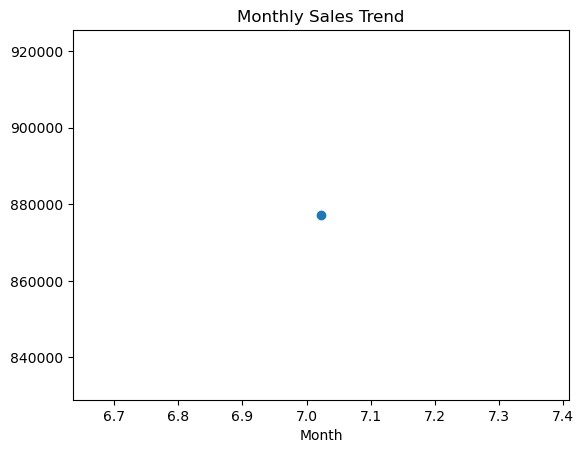

In [27]:
monthly_sales.plot(kind="line", marker="o")
plt.title("Monthly Sales Trend")
plt.show()

QUARTERLY SALES ANALYSIS:

In [29]:
quarterly_sales=df.groupby("Quarter")["Sales"].sum()

print(quarterly_sales)

Quarter
2.651685    877216.569767
Name: Sales, dtype: float64


<function matplotlib.pyplot.show(close=None, block=None)>

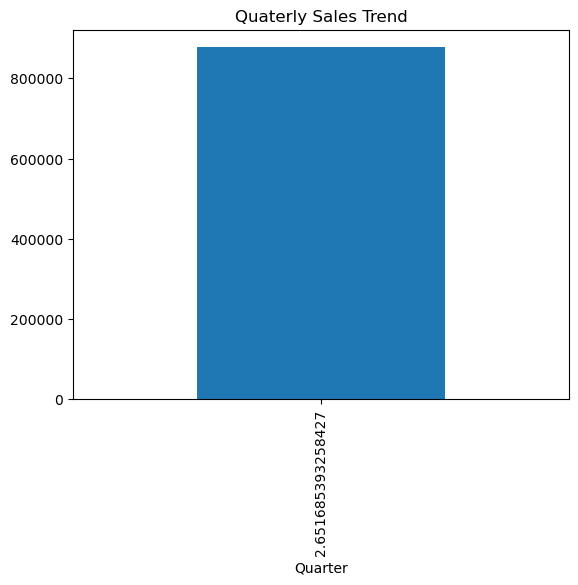

In [30]:
quarterly_sales.plot(kind="bar")
plt.title("Quaterly Sales Trend")
plt.show


YEARLY SALES ANALYSIS:

In [32]:
yearly_sales=df.groupby("Year")["Sales"].sum()
print(yearly_sales)

Year
2024.0    877216.569767
Name: Sales, dtype: float64


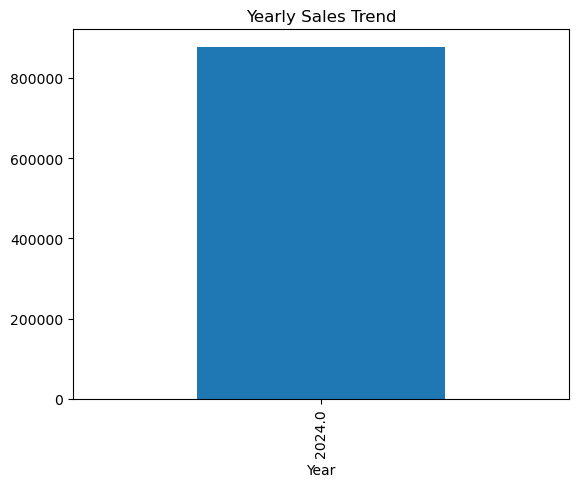

In [33]:
yearly_sales.plot(kind="bar")
plt.title("Yearly Sales Trend")
plt.show()

TOP 10 PRODUCTS:

In [35]:
top_products = (
    df.groupby("Product")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products)

Product
Action Camera      78949.491279
Rubber Bands        8772.165698
Smart Watch         8772.165698
Smart TV 55inch     8772.165698
Smart Speaker       8772.165698
Smart Fridge        8772.165698
Smart Doorbell      8772.165698
Side Table          8772.165698
Shoe Rack           8772.165698
Scissors            8772.165698
Name: Sales, dtype: float64


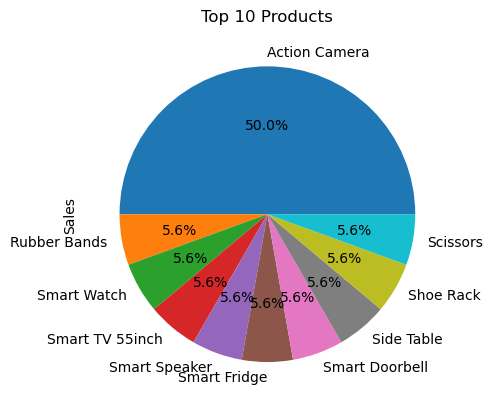

In [36]:
top_products.plot(kind="pie",autopct="%1.1f%%")
plt.title('Top 10 Products')
plt.show()

BOTTOM 10 PRODUCTS:

In [38]:
bottom_products = (
    df.groupby("Product")["Sales"]
    .sum()
    .sort_values()
    .head(10)
)

print(bottom_products)

Product
Office Chair       8772.165698
Smart TV 55inch    8772.165698
Smart Speaker      8772.165698
Smart Fridge       8772.165698
Smart Doorbell     8772.165698
Side Table         8772.165698
Shoe Rack          8772.165698
Scissors           8772.165698
Ruler Set          8772.165698
Rubber Bands       8772.165698
Name: Sales, dtype: float64


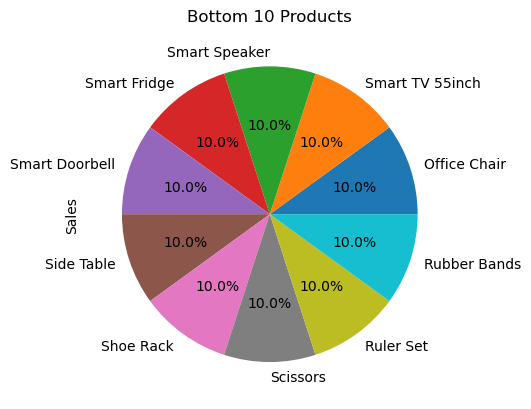

In [39]:
bottom_products.plot(kind="pie",autopct="%1.1f%%")
plt.title("Bottom 10 Products")
plt.show()

CATEGORY WISE SALES:

In [41]:
category_sales = df.groupby("Category")["Sales"].sum()
print(category_sales)

Category
Furniture          359658.793605
Office Supplies    245620.639535
Technology         271937.136628
Name: Sales, dtype: float64


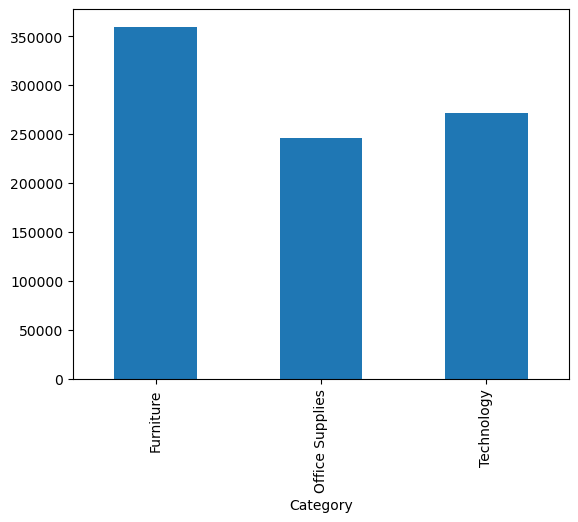

In [42]:
category_sales.plot(kind="bar")
plt.title=("Category Wise Sales")
plt.show()

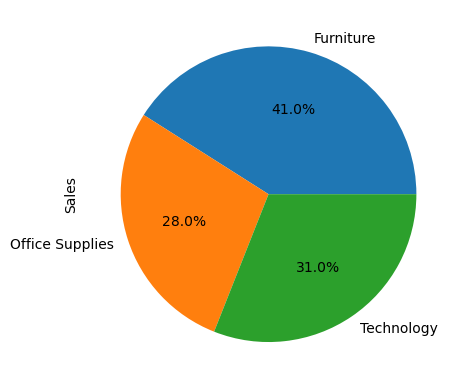

In [43]:
category_sales.plot(kind="pie", autopct="%1.1f%%")
plt.show()

REGION WISE SALES:

In [45]:
region_sales=df.groupby("Region")["Sales"].sum()

print(region_sales)

Region
East     289481.468023
North    210531.976744
South    184215.479651
West     192987.645349
Name: Sales, dtype: float64


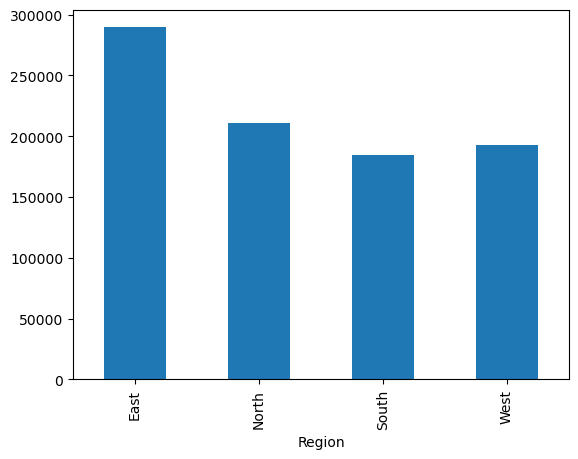

In [46]:
region_sales.plot(kind="bar")
plt.title=("Region Wise Sales")
plt.show()

REGION Vs CATEGORU ANALYSIS:

In [48]:
pivot_table = pd.pivot_table(
    df,
    values="Sales",
    index="Region",
    columns="Category",
    aggfunc="sum"
)

print(pivot_table)

Category      Furniture  Office Supplies    Technology
Region                                                
East      105265.988372     87721.656977  96493.822674
North      96493.822674     43860.828488  70177.325581
South      61405.159884     70177.325581  52632.994186
West       96493.822674     43860.828488  52632.994186


TypeError: 'str' object is not callable

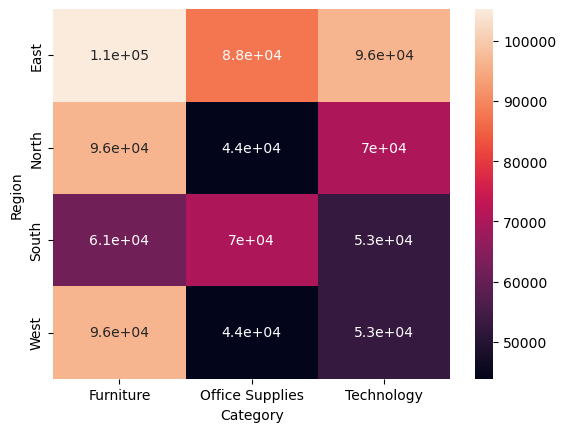

In [49]:
sns.heatmap(pivot_table, annot=True)
plt.title("Region vs Category Sales")
plt.show()

KPI CALCULATIONS:

In [ ]:
revenue = df["Sales"].sum()

In [ ]:
profit = df["Profit"].sum()

In [ ]:
orders = df["Order ID"].nunique()

In [ ]:
avg_order_value = revenue / orders

In [ ]:
profit_margin = (profit / revenue) * 100

In [ ]:
yearly_sales = yearly_sales.reset_index()

yearly_sales["Growth Rate"] = (
    yearly_sales["Sales"].pct_change() * 100
)

In [50]:
df.to_csv("cleaned_sales_data.csv", index=False)